In [1]:
import os
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Paths
csv_path = "Data_Entry_2017_v2020.csv"
img_dir = "images"

# Load CSV
df = pd.read_csv(csv_path)

# Filter only images that exist in your current folder
available_imgs = set(os.listdir(img_dir))
df = df[df['Image Index'].isin(available_imgs)]

In [2]:
from scipy.stats import mode

# Step 1: Define target labels
target_labels = ['Pneumonia', 'Infiltration', 'Consolidation', 'Effusion', 'No Finding']

def is_valid_entry(label_str):
    return any(lbl in label_str.split('|') for lbl in target_labels)

def extract_multiclass_label(label_str):
    labels = label_str.split('|')
    for i, disease in enumerate(target_labels):
        if disease in labels:
            return i
    return len(target_labels) - 1  # No Finding

df = df[df['Finding Labels'].apply(is_valid_entry)]
df['label'] = df['Finding Labels'].apply(extract_multiclass_label)

def most_common_label(x):
    counts = x.value_counts()
    if len(counts) == 0:
        return x.iloc[0]  # fallback (should rarely happen)
    return counts.idxmax()  # picks first in case of tie

patient_df = df.groupby('Patient ID')['label'].agg(most_common_label).reset_index()

# Step 4: Stratified split by patient label
train_patients, val_patients = train_test_split(
    patient_df,
    test_size=0.2,
    stratify=patient_df['label'],
    random_state=42
)

# Step 5: Split original DataFrame
train_df = df[df['Patient ID'].isin(train_patients['Patient ID'])]
val_df = df[df['Patient ID'].isin(val_patients['Patient ID'])]

In [3]:
from torch.utils.data import WeightedRandomSampler

# Count how often each class appears in the training set
label_counts = np.zeros(len(target_labels))
for labels in train_df['Finding Labels']:
    for i, disease in enumerate(target_labels):
        if disease in labels.split('|'):
            label_counts[i] += 1

# Inverse frequency = rarer class gets higher weight
class_weights = 1.0 / label_counts
print("Class weights (inverse frequency):", class_weights)

# Assign a sampling weight to each training sample
sample_weights = []
for labels in train_df['Finding Labels']:
    weight = 0.0
    for i, disease in enumerate(target_labels):
        if disease in labels.split('|'):
            weight += class_weights[i]
    sample_weights.append(weight)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class weights (inverse frequency): [0.02083333 0.0015015  0.00595238 0.00244499 0.00045767]


In [4]:
# Print summary
print(f"Train images: {len(train_df)}, Val images: {len(val_df)}")
print(f"Train patients: {len(train_patients)}, Val patients: {len(val_patients)}\n")

print("Train class distribution:")
print(train_df['label'].value_counts())

print("\nValidation class distribution:")
print(val_df['label'].value_counts())

Train images: 3263, Val images: 813
Train patients: 969, Val patients: 243

Train class distribution:
label
4    2185
1     651
3     262
2     117
0      48
Name: count, dtype: int64

Validation class distribution:
label
4    569
1    156
3     42
2     29
0     17
Name: count, dtype: int64


In [5]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, target_labels=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.target_labels = target_labels  # ✅ must store this

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        labels = self.df.loc[idx, 'Finding Labels'].split('|')
        target = torch.zeros(len(self.target_labels), dtype=torch.float32)
        for i, disease in enumerate(self.target_labels):
            if disease in labels:
                target[i] = 1.0

        return image, target

In [6]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# No augmentation for validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = ChestXrayDataset(train_df, img_dir, train_transform, target_labels)
val_dataset = ChestXrayDataset(val_df, img_dir, val_transform, target_labels)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [7]:
from collections import Counter
import torch

label_counter = Counter()
n_batches = 10  # check more batches if you like

for i, (images, targets) in enumerate(train_loader):
    if i >= n_batches:
        break
    for t in targets:
        for idx, val in enumerate(t):
            if val == 1:
                label_counter[idx] += 1

print("\nSampled label distribution (approximate, from batches):")
for i, label in enumerate(target_labels):
    print(f"{label:15}: {label_counter[i]}")


Sampled label distribution (approximate, from batches):
Pneumonia      : 43
Infiltration   : 52
Consolidation  : 29
Effusion       : 36
No Finding     : 44


In [8]:
def train_one_epoch(loader, model, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in tqdm(loader, desc=f"Epoch {epoch+1} [Train]", leave=False):
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # shape: [B, num_classes]
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.sigmoid(outputs) > 0.5  # threshold logits for multi-label
        correct += (preds == targets.bool()).sum().item()
        total += targets.numel()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    print(f"Epoch {epoch+1} - Train Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc*100:.2f}%")

    return epoch_loss, epoch_acc


In [10]:
from torchvision.models import googlenet, GoogLeNet_Weights
import torch.nn as nn

def get_modified_googlenet(num_classes):
    weights = GoogLeNet_Weights.DEFAULT
    model = googlenet(weights=weights, transform_input=False)

    # First conv for grayscale
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Final layer for multi-label output
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


In [12]:
from torch.optim.lr_scheduler import StepLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_modified_googlenet(num_classes=len(target_labels)).to(device)

# Compute pos_weight for each class
total_samples = len(train_df)
pos_counts = np.zeros(len(target_labels), dtype=np.float32)

for label_str in train_df['Finding Labels']:
    labels_present = [int(label in label_str.split('|')) for label in target_labels]
    pos_counts += np.array(labels_present)

neg_counts = total_samples - pos_counts
# Add small epsilon to avoid division by zero
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5), dtype=torch.float32).to(device)

print("Pos weights per class:", pos_weight.cpu().numpy())

# Loss, optimizer, scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

num_epochs = 10
best_acc = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(train_loader, model, optimizer, criterion, device, epoch)
    val_acc = evaluate(val_loader, model, criterion, device, epoch)

    scheduler.step()
    print(f"Learning Rate after Epoch {epoch+1}: {scheduler.get_last_lr()[0]:.5f}")

    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

Pos weights per class: [66.97915     3.8993993  18.422617    6.977995    0.49336386]


Epoch 1 - Train Loss: 1.6668 | Accuracy: 39.41%


Epoch 1 - Val Loss: 1.3670 | Accuracy: 19.29%
Learning Rate after Epoch 1: 0.00010


Epoch 2 - Train Loss: 1.2568 | Accuracy: 47.13%


Epoch 2 - Val Loss: 1.4342 | Accuracy: 30.55%
Learning Rate after Epoch 2: 0.00010


...

Epoch 9 - Train Loss: 0.6171 | Accuracy: 76.90%


Epoch 9 - Val Loss: 1.7455 | Accuracy: 56.26%
Learning Rate after Epoch 9: 0.00001


Epoch 10 - Train Loss: 0.5788 | Accuracy: 78.43%


Epoch 10 - Val Loss: 1.6267 | Accuracy: 57.84%
Learning Rate after Epoch 10: 0.00001


GoogLeNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (branch2): Sequential(
      (0): BasicConv2d(
        (conv): Conv2d(192, 96, kernel_si

Collected probs and targets:
all_probs shape: (813, 5)
all_targets shape: (813, 5)


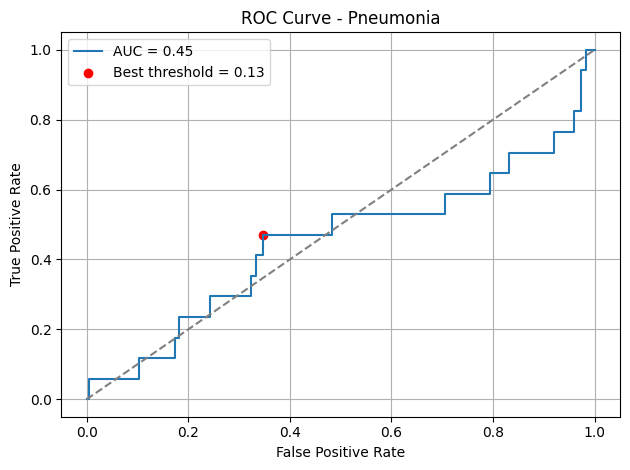

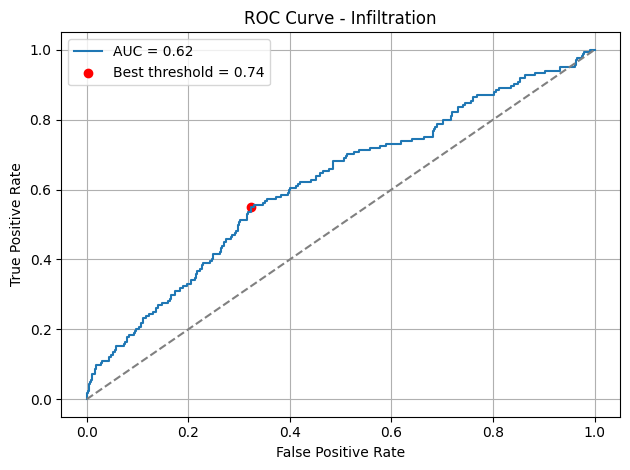

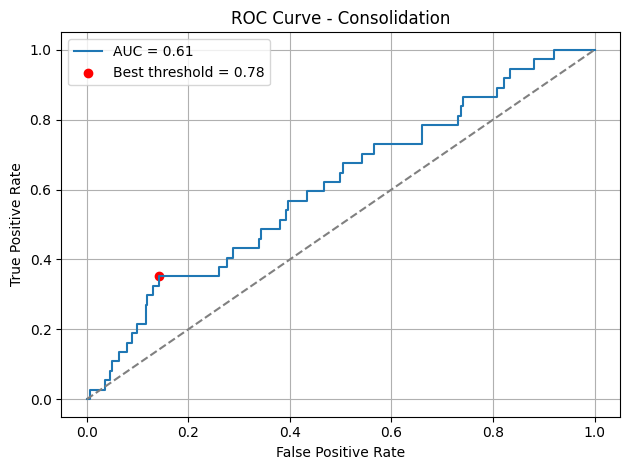

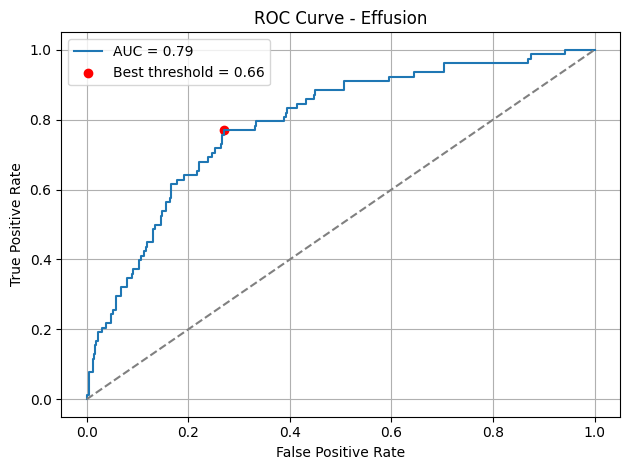

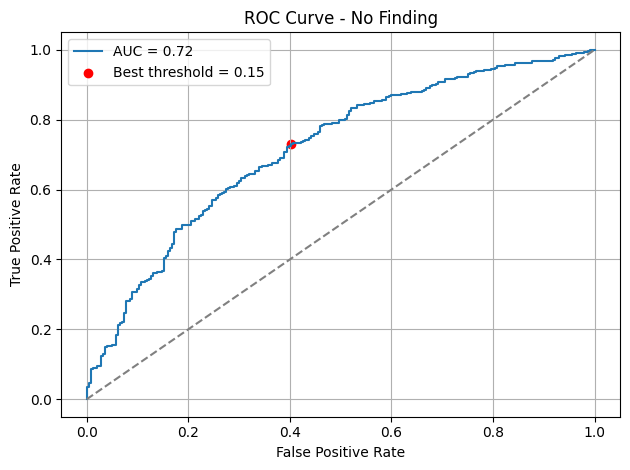

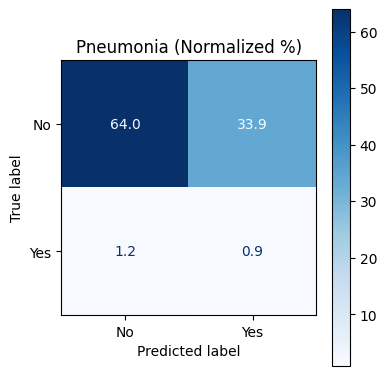

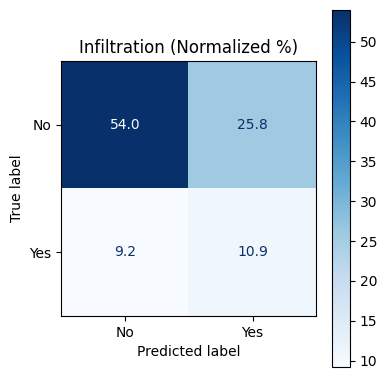

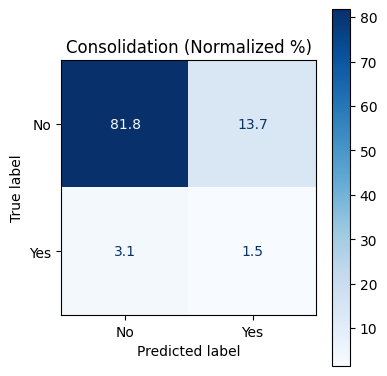

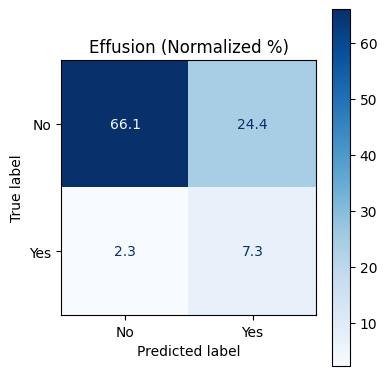

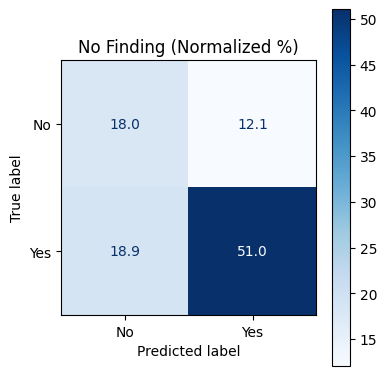

               precision    recall  f1-score   support

    Pneumonia     0.0247    0.4118    0.0467        17
 Infiltration     0.2977    0.5427    0.3844       164
Consolidation     0.0976    0.3243    0.1500        37
     Effusion     0.2296    0.7564    0.3522        78
   No Finding     0.8090    0.7293    0.7671       569

    micro avg     0.3946    0.6728    0.4974       865
    macro avg     0.2917    0.5529    0.3401       865
 weighted avg     0.6139    0.6728    0.6166       865
  samples avg     0.4545    0.6769    0.5201       865



In [30]:
from sklearn.metrics import roc_curve, auc, multilabel_confusion_matrix, ConfusionMatrixDisplay

# Step 1: Collect raw probabilities and true labels
all_probs = []
all_targets = []

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(targets.numpy())

all_probs = np.vstack(all_probs)
all_targets = np.vstack(all_targets)

print("Collected probs and targets:")
print("all_probs shape:", all_probs.shape)
print("all_targets shape:", all_targets.shape)

# Step 2: Compute optimal thresholds from ROC curves
optimal_thresholds = []
for i, label in enumerate(target_labels):
    fpr, tpr, thresholds = roc_curve(all_targets[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    youden_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[youden_idx]
    optimal_thresholds.append(best_thresh)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.scatter(fpr[youden_idx], tpr[youden_idx], color='red', label=f"Best threshold = {best_thresh:.2f}")
    plt.title(f"ROC Curve - {label}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Convert to NumPy array for broadcasting
optimal_thresholds = np.array(optimal_thresholds)

# Step 3: Apply thresholds to get predictions
final_preds = (all_probs > optimal_thresholds).astype(int)

# Step 4: Compute and display confusion matrices
conf_matrices = multilabel_confusion_matrix(all_targets, final_preds)

for i, label in enumerate(target_labels):
    cm = conf_matrices[i].astype(np.float32)
    cm_sum = cm.sum()
    cm_percent = (cm / cm_sum * 100) if cm_sum > 0 else cm

    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=["No", "Yes"]
    )
    disp.plot(cmap="Blues", values_format=".1f", ax=ax)
    ax.set_title(f"{label} (Normalized %)")
    plt.tight_layout()
    plt.show()

# Optional: Print classification report with new thresholds
from sklearn.metrics import classification_report
print(classification_report(
    all_targets,
    final_preds,
    target_names=target_labels,
    digits=4,
    zero_division=0
))
